# Xunzi Fine-tuning (EVAHAN)
Notebook này chuẩn hoá pipeline fine-tune cho bài toán **phân tách từ + phục hồi dấu câu** trên cổ văn.

Mô hình sử dụng: **Xunzi-Qwen3-8B**

**Luồng xử lý**
- Cài đặt → import/seed
- Nạp & chuẩn hoá dữ liệu EVAHAN
- (Tuỳ chọn) SPEADO retriever để chèn 1 ví dụ tham chiếu vào prompt
- Tạo prompt ChatML → load model (Unsloth) → gắn LoRA
- Fine-tune → lưu artifacts/model → zip để tải về

## 1) Cài đặt phụ thuộc

In [1]:
!pip install "unsloth[kaggle-new] @ git+https://github.com/unslothai/unsloth.git" --quiet
!pip install --no-deps "xformers" "trl<0.9.0" "accelerate" "bitsandbytes" --quiet
!pip install datasketch jiwer seqeval opencc-python-reimplemented --quiet

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.8/293.8 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.3/199.3 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 102.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.9/224.9 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.7/146.7 kB 6.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the f

## 2) Imports & thiết lập môi trường
- Thiết lập biến môi trường GPU/Unsloth.
- Import các thư viện cần thiết và cố định seed để tái lập kết quả.
- Áp dụng một hotfix tương thích version cho `peft.LoraConfig` (không đổi logic train).

In [2]:
import os

# GPU (tuỳ chọn)
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["UNSLOTH_RETURN_LOGITS"] = "1"

from unsloth import FastLanguageModel # inport thư viện Unsloth trước các thư viện khác để tránh lỗi

import json
import re
from typing import Iterable, Optional, Tuple

import numpy as np
import torch
import torch.nn.functional as F
from datasketch import MinHash, MinHashLSH
from tqdm.auto import tqdm

from datasets import Dataset
from sklearn.model_selection import train_test_split
from transformers import TrainingArguments
from trl import DataCollatorForCompletionOnlyLM, SFTTrainer

# --- Compatibility hotfix (Unsloth / PEFT) ---
# Một số version PEFT có tham số `ensure_weight_tying` khác nhau. Hotfix này chỉ bỏ kwargs gây lỗi,
# không thay đổi logic fine-tune.
from peft import LoraConfig

if not hasattr(LoraConfig.__init__, "_is_patched_by_user"):
    _original_init = LoraConfig.__init__

    def _safe_init(self, *args, **kwargs):
        kwargs.pop("ensure_weight_tying", None)
        _original_init(self, *args, **kwargs)

    _safe_init._is_patched_by_user = True
    LoraConfig.__init__ = _safe_init

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


2026-01-03 18:25:25.737672: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767464726.176384      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767464726.307323      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767464727.519851      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767464727.519899      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767464727.519901      24 computation_placer.cc:177] computation placer alr

🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth: Could not import trl.trainer.ddpo_trainer: Failed to import trl.trainer.ddpo_trainer because of the following error (look up to see its traceback):
Failed to import trl.models.modeling_sd_base because of the following error (look up to see its traceback):
Failed to import diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion because of the following error (look up to see its traceback):
Failed to import diffusers.loaders.ip_adapter because of the following error (look up to see its traceback):
/usr/local/lib/python3.12/dist-packages/xformers/flash_attn_3/_C.so: undefined symbol: _ZNK3c106SymInt22maybe_as_int_slow_pathEv


/usr/local/lib/python3.12/dist-packages/sqlalchemy/orm/query.py:195: SyntaxWarning: "is not" with 'tuple' literal. Did you mean "!="?
  if entities is not ():


## 3) Cấu hình
Gom hyperparameters và đường dẫn dữ liệu vào một nơi để dễ tái sử dụng/chỉnh sửa.

In [3]:
class Config:
    # Model
    MODEL_NAME = "/kaggle/input/xunzi-qwen3-8b/pytorch/default/1/Xunzi-Qwen3-8B"
    MAX_SEQ_LENGTH = 1024
    DTYPE = None  # auto-detect
    LOAD_IN_4BIT = True

    # SPEADO / retrieval
    NUM_PERM = 128
    TOP_K_EXAMPLE = 1  # hiện tại notebook dùng 1 ví dụ tham chiếu
    RETRIEVAL_SIM_THRESHOLD = 0.5  # không chèn ref nếu similarity thấp (giảm noise prompt)

    # Training
    OUTPUT_DIR = "xunzi-qwen3-8b-finetune-evahan"
    ARTIFACTS_DIR = "training_artifacts"
    BATCH_SIZE = 1
    GRAD_ACCUMULATION = 1
    LEARNING_RATE = 2e-4
    EPOCHS = 2

    # Data paths (EvaHAN)
    EVAHAN_PATH = ["/kaggle/input/evahan-2022/evahan_train.json", "/kaggle/input/wenyanbench/EvaHan/zuozhuan_train_utf8.json"]

## 4) Chuẩn hoá dữ liệu & SPEADO retriever (EVAHAN-only)
Mục tiêu: đưa dữ liệu về 2 trường thống nhất:
- `raw`: bỏ POS + bỏ dấu câu/space (chuỗi ký tự gốc)
- `target`: bỏ POS, **giữ** dấu câu + khoảng trắng phân tách

Sau đó dựng MinHash LSH retriever để lấy **tối đa 1** ví dụ tương đồng làm “Reference Example” trong prompt (chỉ chèn khi similarity đủ cao để tránh nhiễu).

In [4]:
# Note: `CJK_PUNCT` được dùng nhất quán cho:
# - chuẩn hoá dữ liệu (strip punctuation)
CJK_PUNCT = {
    '"', '(', ')', ',', '-', ':',
    '、', '。',
    '〈', '〉', '《', '》',
    '「', '」', '『', '』',
    '〔', '〕',
    '\ue3ed', '\ue3f0', '\ue3ff',
    '！', '（', '）', '，', '．', '：', '；', '？',
}


def strip_pos_tags(text: str) -> str:
    """Remove EvaHan POS tags (e.g., '/v', '/nr') and normalize whitespace."""
    text = re.sub(r"/[a-z]+", "", text)
    return re.sub(r"\s+", " ", text).strip()


def strip_punctuation(text: str) -> str:
    """Remove common Chinese punctuation and spaces."""
    return "".join(ch for ch in text if ch not in CJK_PUNCT and ch != " ")


def _build_minhash_from_text(text: str, *, num_perm: int) -> MinHash:
    """Build MinHash from a character stream (fast and memory-friendly)."""
    m = MinHash(num_perm=num_perm)
    for ch in text:
        m.update(ch.encode("utf-8"))
    return m


def _jaccard_char_set(a: str, b: str) -> float:
    """Actual Jaccard similarity on character sets (robust rescoring)."""
    sa = set(a)
    sb = set(b)
    if not sa and not sb:
        return 1.0
    if not sa or not sb:
        return 0.0
    return len(sa & sb) / max(1, len(sa | sb))


class SpeadoExampleRetriever:
    """MinHash LSH retriever + robust Jaccard rescoring.

    - LSH dùng để lấy candidate nhanh.
    - Sau đó tính Jaccard "thực" (set ký tự) để chọn best candidate.
    - Nếu best_score < min_score_threshold => không chèn reference (giảm prompt noise).
    """

    def __init__(
        self,
        data_list,
        *,
        threshold: float = 0.5,
        min_score_threshold: float = 0.5,
        verbose: bool = True,
    ):
        self.min_score_threshold = float(min_score_threshold)
        self._lsh = MinHashLSH(threshold=threshold, num_perm=Config.NUM_PERM)
        self._minhashes: dict[str, MinHash] = {}
        self._targets: dict[str, str] = {}
        self._raw_targets: dict[str, str] = {}

        if verbose:
            print("[SPEADO] Building MinHash index...")
        for idx, item in enumerate(tqdm(data_list, disable=not verbose)):
            target = item["target"]
            raw_target = strip_punctuation(target)
            m = _build_minhash_from_text(raw_target, num_perm=Config.NUM_PERM)
            key = str(idx)
            self._lsh.insert(key, m)
            self._minhashes[key] = m
            self._targets[key] = target
            self._raw_targets[key] = raw_target

    def retrieve_with_score(self, raw_input: str) -> Tuple[Optional[str], float]:
        """Return (best_target, best_score) where best_score is actual Jaccard."""
        # 1) Candidate pruning with MinHash LSH
        q_mh = _build_minhash_from_text(raw_input, num_perm=Config.NUM_PERM)
        candidate_ids = self._lsh.query(q_mh)
        if not candidate_ids:
            return None, 0.0

        # 2) Robust rescoring with actual Jaccard on char-set
        best_id = None
        best_score = -1.0
        for cid in candidate_ids:
            cand_raw = self._raw_targets[cid]
            score = _jaccard_char_set(raw_input, cand_raw)
            if score > best_score:
                best_score = score
                best_id = cid

        if best_id is None:
            return None, 0.0

        # Avoid trivial exact copy (no augmentation gain)
        if self._raw_targets[best_id] == raw_input:
            return None, float(best_score)

        # Threshold to avoid noisy reference injection
        if best_score < self.min_score_threshold:
            return None, float(best_score)

        return self._targets[best_id], float(best_score)

    def retrieve(self, raw_input: str) -> Optional[str]:
        """Backward-compatible API: returns target only (no score)."""
        target, _ = self.retrieve_with_score(raw_input)
        return target


def _normalize_evahan_paths(evahan_path):
    """Normalize EVAHAN_PATH (str | list[str] | None) into list[str]."""
    if evahan_path is None:
        return []
    if isinstance(evahan_path, (str, os.PathLike)):
        p = str(evahan_path).strip()
        return [p] if p else []
    if isinstance(evahan_path, (list, tuple, set)):
        paths = []
        for p in evahan_path:
            if p is None:
                continue
            s = str(p).strip()
            if s:
                paths.append(s)
        return paths
    raise TypeError(
        f"EVAHAN_PATH must be str | list[str] | None, got {type(evahan_path)}"
    )


def load_evahan_dataset(
    evahan_path=None,
    *,
    verbose: bool = True,
 ):
    """Load EVAHAN-style JSON file(s) and normalize to samples[{raw,target}].

    evahan_path can be:
    - str: one json path
    - list[str]: multiple json paths (merged)
    - None: uses Config.EVAHAN_PATH

    Supported item formats inside each file:
    - EVAHAN: [{'input': str, 'output': str}, ...] where output contains POS tags and punctuation tokens.
    - Already-normalized: [{'raw': str, 'target': str}, ...]
    """
    samples = []
    if evahan_path is None:
        evahan_path = Config.EVAHAN_PATH

    paths = _normalize_evahan_paths(evahan_path)
    if not paths:
        return samples

    if verbose:
        print(f"[Data] EVAHAN files: {len(paths)}")

    for path in paths:
        if not os.path.exists(path):
            raise FileNotFoundError(f"[Data] EVAHAN file not found: {path}")

        if verbose:
            print(f"[Data] EVAHAN: {path}")

        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)

        for item in data:
            # Case 1) Already-normalized format
            if "raw" in item and "target" in item:
                raw_clean = strip_punctuation(str(item["raw"]))
                target_clean = strip_pos_tags(str(item["target"]))
                if raw_clean and target_clean:
                    samples.append({"raw": raw_clean, "target": target_clean})
                continue

            # Case 2) EVAHAN raw format
            if "input" in item and "output" in item:
                target_clean = strip_pos_tags(str(item["output"]))
                # For stability/alignment: derive raw from cleaned target
                raw_clean = strip_punctuation(target_clean)
                if raw_clean and target_clean:
                    samples.append({"raw": raw_clean, "target": target_clean})
                continue

            # Ignore unknown rows
            continue

    if verbose:
        print(f"[Data] Total EVAHAN samples (merged): {len(samples)}")
    return samples


all_dataset = load_evahan_dataset()

[Data] EVAHAN files: 2
[Data] EVAHAN: /kaggle/input/evahan-2022/evahan_train.json
[Data] EVAHAN: /kaggle/input/wenyanbench/EvaHan/zuozhuan_train_utf8.json
[Data] Total EVAHAN samples (merged): 9570


### 4.1) Split dữ liệu → chunking (chống leakage)
- **Split trước** khi chunk để tránh các đoạn overlap rơi vào cả train và val.
- Chunking dùng *hard sliding window* để đảm bảo alignment `raw` ↔ `target` theo từng ký tự.
- Retriever được build **chỉ trên train chunks** để tránh "nhìn trộm" val.

In [5]:
# --- Split-before-chunking (anti-leakage) ---
# Split raw → chunk separately → build retriever on TRAIN only.

def build_index_mapping(raw_text: str, target_text: str):
    """
    Map each index i of `raw_text` to the corresponding index in `target_text`.

    We keep strict character alignment by skipping punctuation/separators in `target_text`
    that do not exist in `raw_text`.

    Returns:
        mapping: list[int] where mapping[i] = j and raw_text[i] == target_text[j].
    """
    mapping = []
    t_ptr = 0
    t_len = len(target_text)
    for r_char in raw_text:
        # `raw_text` is expected to be punctuation-free; this is a safe guardrail.
        if r_char in CJK_PUNCT:
            continue
        while t_ptr < t_len:
            if target_text[t_ptr] == r_char:
                mapping.append(t_ptr)
                t_ptr += 1
                break
            # Skip punctuation / separators in target until we find the same char.
            t_ptr += 1
    return mapping


def apply_hard_sliding_window(
    dataset_list,
    max_seq_len: int,
    overlap: int = 256,
    reserved_tokens: int = 200,
):
    """Chunk samples with a fixed-size sliding window on `raw`, then slice `target` by alignment.

    Notes:
    - `reserved_tokens` leaves room for prompt overhead (system/user headers + ref example).
    - `overlap` improves continuity but must be < chunk_size.
    """
    chunk_size = int(max_seq_len) - int(reserved_tokens)
    if chunk_size <= 0:
        raise ValueError(
            f"chunk_size must be > 0, got {chunk_size}. "
            "Check max_seq_len/reserved_tokens."
        )
    if overlap < 0:
        raise ValueError(f"overlap must be >= 0, got {overlap}.")
    if overlap >= chunk_size:
        raise ValueError(f"overlap ({overlap}) must be < chunk_size ({chunk_size}).")
    stride = chunk_size - overlap
    new_samples = []

    for item in tqdm(dataset_list, desc="Hard Chunking"):
        raw = item["raw"]
        target = item["target"]

        mapping = build_index_mapping(raw, target)
        # If alignment fails, skip this row (keeps training stable).
        if len(mapping) != len(raw):
            continue

        n_chars = len(raw)
        for start_idx in range(0, n_chars, stride):
            end_idx = min(start_idx + chunk_size, n_chars)

            chunk_raw = raw[start_idx:end_idx]

            # Slice target based on aligned indices (raw indices -> target indices).
            t_start = mapping[start_idx]
            t_end_char = mapping[end_idx - 1]
            t_end = t_end_char + 1

            # Extend until after trailing punctuation for cleaner chunk boundaries.
            while t_end < len(target) and target[t_end] in CJK_PUNCT:
                t_end += 1

            chunk_target = target[t_start:t_end]

            # Drop too-short chunks unless it's the final chunk.
            if len(chunk_raw) < 10 and end_idx < n_chars:
                continue

            new_samples.append({"raw": chunk_raw, "target": chunk_target})

            if end_idx == n_chars:
                break

    return new_samples


print(f"[Data] Original samples: {len(all_dataset)}")

train_data_raw, val_data_raw = train_test_split(
    all_dataset, test_size=0.1, random_state=SEED
)
print(f"[Data] Raw split → Train: {len(train_data_raw)} | Val: {len(val_data_raw)}")

train_chunks = apply_hard_sliding_window(
    train_data_raw,
    max_seq_len=Config.MAX_SEQ_LENGTH,
    overlap=getattr(Config, "OVERLAP", 256),
    reserved_tokens=200,
)
val_chunks = apply_hard_sliding_window(
    val_data_raw,
    max_seq_len=Config.MAX_SEQ_LENGTH,
    overlap=getattr(Config, "OVERLAP", 256),
    reserved_tokens=200,
)
print(f"[Data] Chunked → Train: {len(train_chunks)} | Val: {len(val_chunks)}")

print("[SPEADO] Building retriever on TRAIN only...")
retriever = SpeadoExampleRetriever(
    train_chunks,
    verbose=True,
    min_score_threshold=Config.RETRIEVAL_SIM_THRESHOLD,
)

[Data] Original samples: 9570
[Data] Raw split → Train: 8613 | Val: 957


Hard Chunking:   0%|          | 0/8613 [00:00<?, ?it/s]

Hard Chunking:   0%|          | 0/957 [00:00<?, ?it/s]

[Data] Chunked → Train: 8613 | Val: 957
[SPEADO] Building retriever on TRAIN only...
[SPEADO] Building MinHash index...


  0%|          | 0/8613 [00:00<?, ?it/s]

## 5) Prompt + load model (Unsloth)
Phần này thực hiện:
- Tạo prompt theo ChatML (Qwen) và chèn **Reference Example** nếu retriever tìm được mẫu đủ tương đồng.
- Load base model bằng Unsloth và gắn LoRA.
- Dùng `DataCollatorForCompletionOnlyLM` để chỉ tính loss trên phần **assistant completion**.

In [6]:
# 5) Prompt + load model (Unsloth)
# - Completion-only loss (mask prompt) via DataCollatorForCompletionOnlyLM
# - Retrieval thresholding for reference injection
# - Dynamic injection: hide reference instructions/blocks when no example

# Qwen ChatML: assistant message luôn bắt đầu bằng marker này (collator dùng để mask prompt).
RESPONSE_TEMPLATE = "<|im_start|>assistant\n"

# 1) Định nghĩa Template (Dynamic placeholders for reference)
PROMPT_TEMPLATE = """<|im_start|>system
你是一个专业的古代汉语智能助手，专注于古文的“分词”与“标点”任务。

任务要求：
1. **分词规范**：依照EvaHan学术标准，词与词之间使用半角空格 " " 分隔。
2. **标点规范**：仅使用指定标点集合：{valid_puncts}，标点附着在词后，并在标点后添加空格。
3. **原文忠实**：严禁修改、增加或删除原文中的任何汉字，必须保持字符级别的绝对一致。

{sys_ref_instruction}
<|im_end|>
<|im_start|>user
{ref_block}### 待处理文本：
{input}
<|im_end|>
<|im_start|>assistant
{output}<|im_end|>"""

# 2) Xử lý danh sách dấu câu (Thêm khoảng trắng để rõ ràng)
# Lọc bỏ ký tự nhiễu, chỉ giữ lại các dấu câu hiển thị được
filtered_punct = [c for c in CJK_PUNCT if len(c.encode("utf-8")) < 4 and c.isprintable()]
valid_puncts_str = " ".join(sorted(filtered_punct))

print("[Model] Loading via Unsloth...")
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=Config.MODEL_NAME,
    max_seq_length=Config.MAX_SEQ_LENGTH,
    dtype=Config.DTYPE,
    load_in_4bit=Config.LOAD_IN_4BIT,
 )

# Attach LoRA (Unsloth)
model = FastLanguageModel.get_peft_model(
    model,
    r=32,
    # Quy tắc vàng: alpha = 2 * rank (giúp gradient ổn định hơn)
    lora_alpha=64,
    target_modules=[
        # Attention modules (quan trọng nhất)
        "q_proj", "k_proj", "v_proj", "o_proj",
        # MLP modules (quan trọng cho tri thức/facts)
        "gate_proj", "up_proj", "down_proj",
    ],
    lora_dropout=0.0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=42,
    # Qwen thường ổn định với LoRA truyền thống
    use_rslora=False,
 )

# Completion-only collator: chỉ tối ưu phần assistant completion (target).
collator = DataCollatorForCompletionOnlyLM(
    response_template=RESPONSE_TEMPLATE,
    tokenizer=tokenizer,
 )
print("[Collator] DataCollatorForCompletionOnlyLM enabled")


def format_prompt_batch(examples):
    """Build ChatML prompt text for a batch with dynamic reference injection."""
    inputs = examples["raw"]
    outputs = examples["target"]
    texts = []

    for raw_text, target_text in zip(inputs, outputs):
        ref, sim = retriever.retrieve_with_score(raw_text)

        # Dynamic injection: only add reference instructions/blocks when ref exists
        sys_ref_instruction = ""
        ref_block = ""
        if ref is not None and sim >= Config.RETRIEVAL_SIM_THRESHOLD:
            sys_ref_instruction = "请借鉴下文相似范例，学习其断句逻辑与标点模式，并应用于当前标注任务。"
            ref_raw = strip_punctuation(ref)
            example_section = f"原文：{ref_raw}\n标注：{ref}"
            ref_block = f"### 参考范例：\n{example_section}\n\n"

        text = PROMPT_TEMPLATE.format(
            valid_puncts=valid_puncts_str,
            sys_ref_instruction=sys_ref_instruction,
            ref_block=ref_block,
            input=raw_text,
            output=target_text,
        )

        # Masking cho Unsloth
        text = text.replace("<|im_start|>assistant\n", RESPONSE_TEMPLATE, 1)
        text = text + tokenizer.eos_token
        texts.append(text)

    return {"text": texts}

[Model] Loading via Unsloth...
==((====))==  Unsloth 2025.12.10: Fast Qwen3 patching. Transformers: 4.57.1.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.4.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Unsloth 2025.12.10 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.


[Collator] DataCollatorForCompletionOnlyLM enabled


## 6) Tạo train/val dataset
Map các sample `{raw, target}` sang trường `text` theo `PROMPT_TEMPLATE`. Retriever vẫn là **train-only** (đã build ở bước trước).

In [7]:
# Build HF datasets from chunks (retriever is train-only).
train_dataset = Dataset.from_list(train_chunks).map(format_prompt_batch, batched=True)
val_dataset = Dataset.from_list(val_chunks).map(format_prompt_batch, batched=True)

Map:   0%|          | 0/8613 [00:00<?, ? examples/s]

Map:   0%|          | 0/957 [00:00<?, ? examples/s]

## 7) Vẽ loss
Vẽ train/eval loss từ `trainer.state.log_history` và lưu vào thư mục artifacts để tiện theo dõi quá trình học.

In [8]:
import os
import matplotlib.pyplot as plt


def plot_loss_curve(trainer_state, save_dir: str) -> None:
    """Plot train/eval loss from `trainer.state.log_history` and save as PNG."""
    history = trainer_state.log_history
    train_steps, train_loss = [], []
    val_steps, val_loss = [], []

    for log in history:
        if "loss" in log and "step" in log:
            train_steps.append(log["step"])
            train_loss.append(log["loss"])
        if "eval_loss" in log and "step" in log:
            val_steps.append(log["step"])
            val_loss.append(log["eval_loss"])

    plt.figure(figsize=(10, 6))
    if train_loss:
        plt.plot(train_steps, train_loss, label="train", color="tab:blue", alpha=0.8)
    if val_loss:
        plt.plot(val_steps, val_loss, label="eval", color="tab:red", marker="o")
    plt.title("Loss")
    plt.xlabel("step")
    plt.ylabel("loss")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()

    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, "loss_curve.png")
    plt.savefig(save_path)
    plt.show()
    print(f"[Artifacts] Saved: {save_path}")

## 8) Fine-tune
Thiết lập `TrainingArguments`, khởi tạo `SFTTrainer` và chạy train/eval theo cấu hình.

In [9]:
# 8) Fine-tune
# - Standard SFTTrainer (trl) with standard cross-entropy loss
# - Completion-only collator: chỉ tính loss trên assistant completion

print("[Train] Starting...")

# Warmup steps 
train_samples = len(train_dataset)
total_steps = (
    int(Config.BATCH_SIZE)
    * int(Config.GRAD_ACCUMULATION)
    * int(train_samples)
    * int(Config.EPOCHS)
)
warmup_steps = max(1, int(total_steps * 0.05))

train_args_kwargs = dict(
    per_device_train_batch_size=Config.BATCH_SIZE,
    gradient_accumulation_steps=Config.GRAD_ACCUMULATION,
    per_device_eval_batch_size=1,
    eval_accumulation_steps=1,
    warmup_steps=warmup_steps,
    num_train_epochs=Config.EPOCHS,
    learning_rate=Config.LEARNING_RATE,
    fp16=not torch.cuda.is_bf16_supported(),
    bf16=torch.cuda.is_bf16_supported(),
    optim="adamw_8bit",
    adam_beta1=0.9,  # default
    adam_beta2=0.999,  # batch nhỏ thường cần beta2 cao để ổn định
    weight_decay=0.01,
    lr_scheduler_type="cosine",
    group_by_length=True,
    output_dir=Config.OUTPUT_DIR,
    dataloader_num_workers=0,
    eval_strategy="steps",
    eval_steps=400,
    save_strategy="steps",
    save_steps=400,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",
    logging_steps=10,
)
args = TrainingArguments(**train_args_kwargs)


# Initialize Standard SFTTrainer
trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    dataset_text_field="text",
    max_seq_length=Config.MAX_SEQ_LENGTH,
    dataset_num_proc=2,
    packing=False,
    args=args,
    data_collator=collator,
)

trainer_stats = trainer.train()
print("[Train] Done")

[Train] Starting...


Map (num_proc=2):   0%|          | 0/8613 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/957 [00:00<?, ? examples/s]

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 8,613 | Num Epochs = 2 | Total steps = 17,226
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 1
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 1 x 1) = 1
 "-____-"     Trainable parameters = 87,293,952 of 8,278,029,312 (1.05% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss
400,0.032500,0.172249
800,0.834800,0.247861
1200,0.145200,0.184779
1600,0.176500,0.167708
2000,0.091400,0.156206
2400,0.242200,0.150786
2800,0.207400,0.145411
3200,0.098100,0.141881
3600,0.145100,0.137239
4000,0.084000,0.132991


[Train] Done


## 9) Lưu artifacts
- Vẽ loss curve.
- Lưu LoRA adapters + tokenizer.
- Lưu metrics/config gọn nhẹ để tái hiện thí nghiệm.

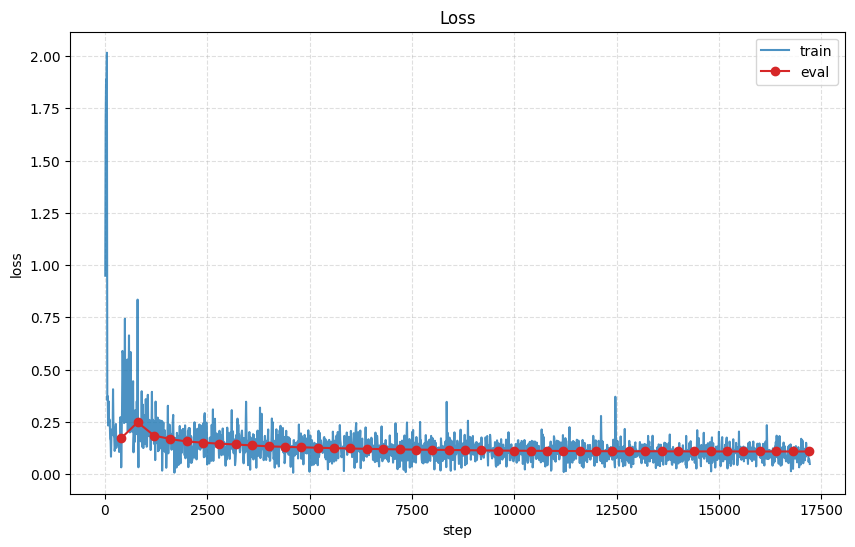

[Artifacts] Saved: training_artifacts/loss_curve.png
[Save] Model adapters → xunzi-qwen3-8b-finetune-evahan
[Artifacts] Saved: training_artifacts/train_metrics.json


In [10]:
plot_loss_curve(trainer.state, Config.ARTIFACTS_DIR)

print(f"[Save] Model adapters → {Config.OUTPUT_DIR}")
model.save_pretrained(Config.OUTPUT_DIR)
tokenizer.save_pretrained(Config.OUTPUT_DIR)

os.makedirs(Config.ARTIFACTS_DIR, exist_ok=True)
metrics_path = os.path.join(Config.ARTIFACTS_DIR, "train_metrics.json")
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(trainer_stats.metrics, f, indent=2, ensure_ascii=False)
print(f"[Artifacts] Saved: {metrics_path}")

## 10) Zip model để tải về
Tạo file `.zip` có tên giống thư mục output (`xunzi-qwen3-8b-finetune-evahan.zip`).

In [11]:
import shutil
from pathlib import Path


def zip_dir(dir_path: str, out_dir: str | None = None, *, overwrite: bool = True) -> str:
    """Zip a directory to `<dir_name>.zip` (same name as folder)."""
    src = Path(dir_path)
    if not src.exists():
        raise FileNotFoundError(f"Not found: {src}")
    if not src.is_dir():
        raise ValueError(f"Not a directory: {src}")

    out_base = Path(out_dir) if out_dir else src.parent
    out_base.mkdir(parents=True, exist_ok=True)

    archive_base = out_base / src.name  # no extension here
    zip_path = archive_base.with_suffix(".zip")
    if overwrite and zip_path.exists():
        zip_path.unlink()

    # make_archive returns the final zip path as string
    return shutil.make_archive(str(archive_base), "zip", root_dir=str(src))


model_zip = zip_dir(Config.OUTPUT_DIR)
print(f"[ZIP] {model_zip}")

[ZIP] /kaggle/working/xunzi-qwen3-8b-finetune-evahan.zip
